# Case Study 2: Uniform Random Numbers

**Scenario:** A dataset of 500 values drawn from a Uniform(0, 1) distribution — the flat distribution that arises from random number generators. This case study illustrates what EDA plots look like for data that is random and independent but *not* normally distributed.

Key insight: EDA checks for *four* assumptions; the distribution assumption can vary — uniform data passes location/scale/independence checks but fails the normality check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

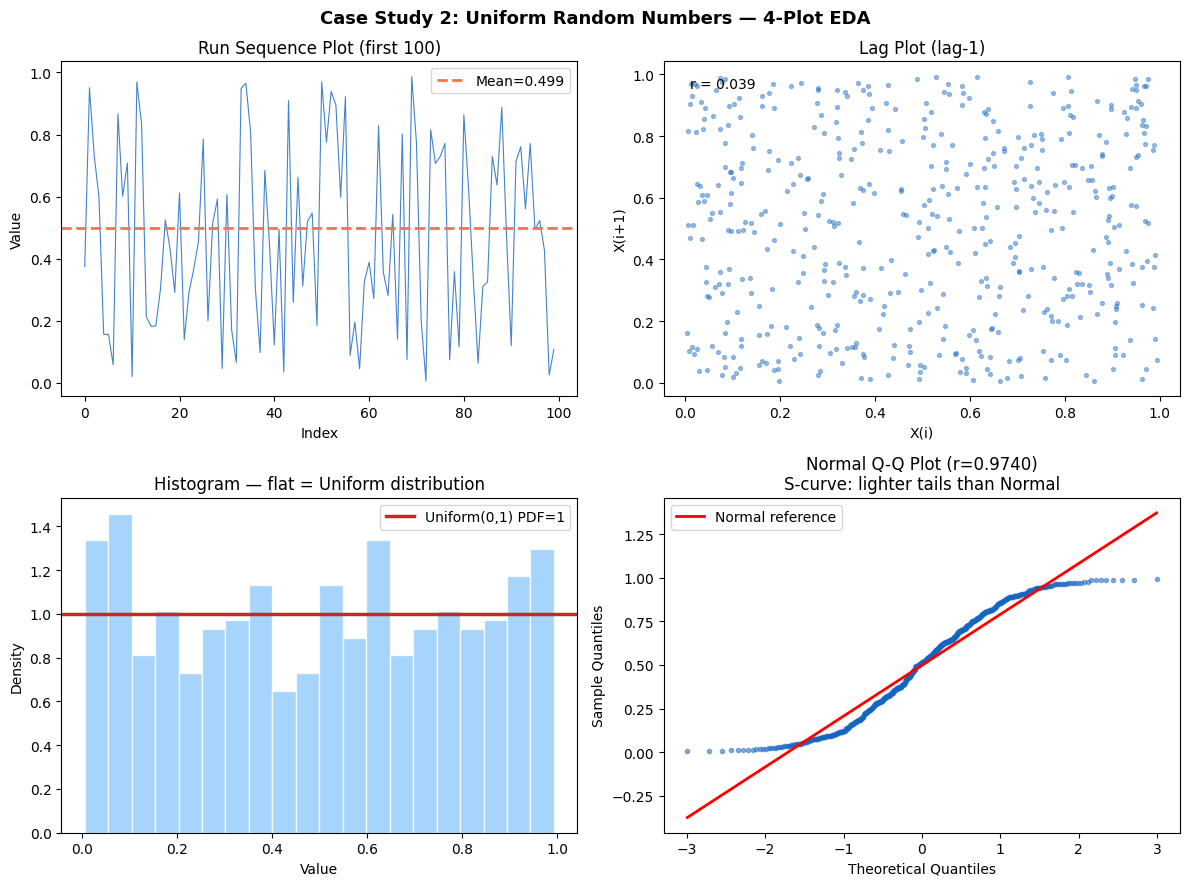

Descriptive: mean=0.4986 (expected 0.5), std=0.2987 (expected 0.2887)
Normality AD A2=6.8800 > crit=0.7810 -> FAIL normality (expected -- data is Uniform)
Uniform KS test: D=0.0421, p=0.3280 -> PASS (data is uniform)
Lag-1 r = 0.0389 -> independence PASS


In [2]:
np.random.seed(42)
n = 500
data = np.random.uniform(0, 1, n)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Case Study 2: Uniform Random Numbers — 4-Plot EDA', fontsize=13, fontweight='bold')

axes[0,0].plot(data[:100], color='#1565C0', lw=0.8, alpha=0.8)
axes[0,0].axhline(data.mean(), color='#FF7043', lw=2, ls='--', label=f'Mean={data.mean():.3f}')
axes[0,0].set_title('Run Sequence Plot (first 100)')
axes[0,0].set_xlabel('Index'); axes[0,0].set_ylabel('Value')
axes[0,0].legend()

axes[0,1].scatter(data[:-1], data[1:], color='#1565C0', s=8, alpha=0.4)
axes[0,1].set_title('Lag Plot (lag-1)')
axes[0,1].set_xlabel('X(i)'); axes[0,1].set_ylabel('X(i+1)')
r_lag = np.corrcoef(data[:-1], data[1:])[0, 1]
axes[0,1].text(0.05, 0.92, f'r = {r_lag:.3f}', transform=axes[0,1].transAxes, fontsize=10)

axes[1,0].hist(data, bins=20, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
axes[1,0].axhline(1.0, color='#C62828', lw=2.5, label='Uniform(0,1) PDF=1')
axes[1,0].set_title('Histogram — flat = Uniform distribution')
axes[1,0].set_xlabel('Value'); axes[1,0].set_ylabel('Density')
axes[1,0].legend()

(osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=3, alpha=0.5)
axes[1,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2, label='Normal reference')
axes[1,1].set_title(f'Normal Q-Q Plot (r={r:.4f})\nS-curve: lighter tails than Normal')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')
axes[1,1].legend()

plt.tight_layout(); plt.show()

ad_stat, ad_crit, _ = stats.anderson(data, dist='norm')
ks_stat, ks_p = stats.kstest(data, 'uniform')
print(f'Descriptive: mean={data.mean():.4f} (expected 0.5), std={data.std(ddof=1):.4f} (expected {1/np.sqrt(12):.4f})')
print(f'Normality AD A2={ad_stat:.4f} > crit={ad_crit[2]:.4f} -> FAIL normality (expected -- data is Uniform)')
print(f'Uniform KS test: D={ks_stat:.4f}, p={ks_p:.4f} -> PASS (data is uniform)')
print(f'Lag-1 r = {r_lag:.4f} -> independence PASS')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Fixed location** | ✅ Pass | No trend in run sequence |
| **Fixed variation** | ✅ Pass | Constant spread throughout |
| **Independence** | ✅ Pass | Lag plot is square (uniform scatter); r ≈ 0 |
| **Normality** | ❌ Fail (expected) | S-shaped Q-Q; flat histogram; AD test rejects |

**Lesson:** The failure of normality does not mean the data is "bad" — it means the *distributional* assumption needs updating. Uniform data is perfectly well-behaved for many statistical purposes. The Q-Q plot S-shape is the diagnostic signature of lighter-than-normal tails.